-「금융분석 AI Agent」 
- 이 과정의 핵심은 Agent 기술 자체보다 금융분석 업무를 Agent로 구현하는 능력에 두겠습니다. 
- 매 차시 만든 결과물이 마지막에 하나의 AI Equity Research Agent로 합쳐지는 프로젝트형 구조입니다.


In [ ]:
# 기업 분석 요청
#      ↓
# Planning Agent
#      ↓
# ┌────────────────────────────┐
# │ 데이터 수집                │
# │ · 주가 / 시장 데이터       │
# │ · 재무제표                 │
# │ · 공시 / 뉴스              │
# └────────────────────────────┘
#      ↓
# ┌────────────────────────────┐
# │ 금융분석 Tools             │
# │ · 수익률 / 변동성          │
# │ · 재무비율                 │
# │ · 성장성                   │
# │ · Valuation                │
# └────────────────────────────┘
#      ↓
# Financial Analyst Agent
#      ↓
# Risk / Critic Agent
#      ↓
# AI Equity Research Report

# 1회차 — 금융분석 업무를 AI Agent로 바꾸기

- 목표: 생성형 AI와 Agent의 차이를 이해하고 금융 애널리스트 업무를 Agent Workflow로 분해합니다.
- LLM → RAG → Tool Calling → Agent → Multi-Agent의 발전 관계를 설명합니다.

In [ ]:
# 기업 이해
#  ↓
# 재무제표 확인
#  ↓
# 재무비율 계산
#  ↓
# 주가 분석
#  ↓
# Valuation
#  ↓
# 뉴스/산업 조사
#  ↓
# Risk 분석
#  ↓
# 투자 의견

- 이것을 Agent 구조로 바꿉니다.

In [ ]:
# Goal
#  ↓
# Planning
#  ↓
# Tool Selection
#  ↓
# Tool Execution
#  ↓
# Observation
#  ↓
# Reasoning
#  ↓
# Final Answer

# 2회차 — 금융 데이터 분석 Tool 만들기

- 2차시 목표: Agent가 사용할 주가 분석 Tool을 Python으로 구현합니다. -->  analyze_stock() 함수 완성
- 금융 개념은 수익률, 누적수익률, 변동성, 최대낙폭(MDD), 이동평균 정도로 제한합니다.

In [ ]:
# 1. 라이브러리 설치

In [ ]:
# !pip install yfinance pandas numpy matplotlib

In [87]:
# 2. 라이브러리 불러오기
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [88]:
# 1) 주가 데이터 수집 함수

In [89]:
stock = yf.download(
    "005930.KS",
    period="1y",
    auto_adjust=True,
    progress=False
)

print(stock.shape)
stock.head()

(243, 5)


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2025-08-14,70712.632812,71008.914794,70317.590171,71008.914794,11946122
2025-08-18,69132.453125,70317.580893,69132.453125,70218.820246,13595591
2025-08-19,69132.453125,69823.777656,68836.171183,69527.495714,10533082
2025-08-20,69626.257812,69823.779111,68539.890669,69231.215215,17445516
2025-08-21,69725.015625,71008.904015,69725.015625,70613.861433,18843833


In [90]:
def get_stock_price(
    ticker,
    start="2025-01-01"
):
    df = yf.download(
        ticker,
        start=start,
        auto_adjust=True,
        progress=False
    )

    if df.empty:
        raise ValueError(
            f"{ticker}의 주가 데이터를 가져오지 못했습니다. "
            "인터넷 연결, ticker, yfinance 버전을 확인하세요."
        )

    return df

In [91]:
stock = get_stock_price("005930.KS")

stock.head()

Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2025-01-02,52107.093750,52302.251404,51033.726650,51424.041959,16630538
2025-01-03,53082.878906,53765.930657,51521.617762,51521.617762,19318046
2025-01-06,54546.562500,54839.298971,52985.301319,53082.880143,19034284
2025-01-07,54058.667969,55912.665607,54058.667969,55424.771491,17030235
2025-01-08,55912.667969,56107.825623,53375.618462,53473.197289,26593553


In [92]:
# 2) 수익률 계산 함수¶

In [93]:
def calculate_return(df):
    result = df.copy()
    
    result["Return"] = (
        result["Close"]
        .pct_change()
    )
    
    return result

In [94]:
stock = calculate_return(stock)

stock[["Close", "Return"]].head()

Price,Close,Return
Ticker,005930.KS,
Date,,
2025-01-02,52107.093750,NaN
2025-01-03,53082.878906,0.018727
2025-01-06,54546.562500,0.027574
2025-01-07,54058.667969,-0.008945
2025-01-08,55912.667969,0.034296


In [ ]:
# 3) 변동성 계산 함수

In [95]:
def calculate_volatility(df):
    
    returns = (
        df["Close"]
        .pct_change()
        .dropna()
    )
    
    volatility = (
        returns.std()
        * np.sqrt(252)
    )
    
    return float(
        volatility.iloc[0]
    )

In [96]:
volatility = calculate_volatility(stock)

print(
    "Annualized Volatility:",
    volatility
)

Annualized Volatility: 0.6131422675269146


In [97]:
# 4) MDD 계산 함수

In [98]:
def calculate_mdd(df):
    
    close = df["Close"]
    
    returns = (
        close
        .pct_change()
        .dropna()
    )
    
    wealth = (
        1 + returns
    ).cumprod()
    
    peak = wealth.cummax()
    
    drawdown = (
        wealth / peak
        - 1
    )
    
    mdd = drawdown.min()
    
    return float(
        mdd.iloc[0]
    )

In [99]:
mdd = calculate_mdd(stock)

print(
    "Maximum Drawdown:",
    mdd
)

Maximum Drawdown: -0.4283357502200055


In [ ]:
# 5) 누적수익률 함수

In [100]:
def calculate_cumulative_return(df):
    
    close = df["Close"]
    
    returns = (
        close
        .pct_change()
        .dropna()
    )
    
    cumulative_return = (
        1 + returns
    ).cumprod() - 1
    
    return cumulative_return

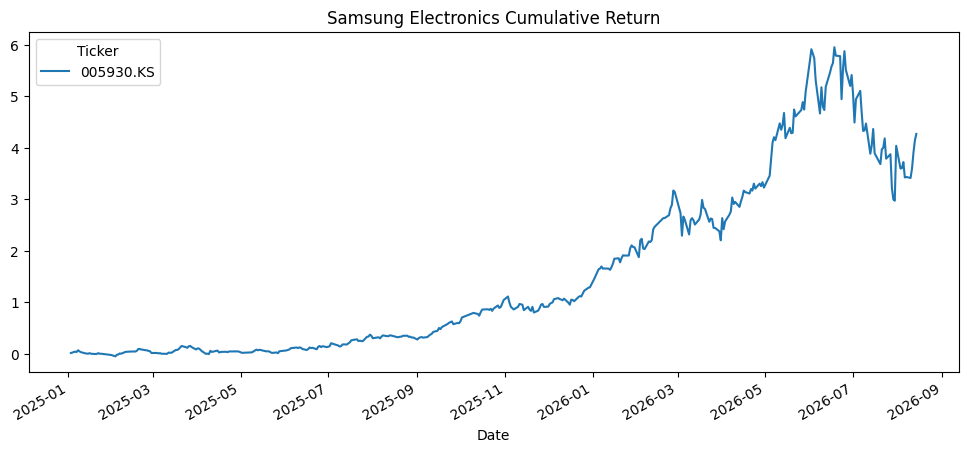

In [101]:
cumulative_return = (
    calculate_cumulative_return(stock)
)

cumulative_return.plot(
    figsize=(12, 5)
)

plt.title(
    "Samsung Electronics Cumulative Return"
)

plt.show()

In [ ]:
# 하나의 금융분석 Tool로 통합

In [102]:
def analyze_stock(
    ticker,
    start="2025-01-01"
):
    
    df = get_stock_price(
        ticker,
        start
    )
    
    close = df["Close"]
    
    returns = (
        close
        .pct_change()
        .dropna()
    )
    
    # 총 수익률
    total_return = (
        close.iloc[-1]
        / close.iloc[0]
        - 1
    )
    
    # 연환산 변동성
    volatility = (
        returns.std()
        * np.sqrt(252)
    )
    
    # MDD
    wealth = (
        1 + returns
    ).cumprod()
    
    peak = wealth.cummax()
    
    drawdown = (
        wealth / peak
        - 1
    )
    
    mdd = drawdown.min()
    
    return {
        "ticker": ticker,
        
        "total_return":
            float(total_return.iloc[0]),
        
        "volatility":
            float(volatility.iloc[0]),
        
        "mdd":
            float(mdd.iloc[0])
    }

In [103]:
result = analyze_stock(
    "005930.KS"
)

result

{'ticker': '005930.KS',
 'total_return': 4.267996739887264,
 'volatility': 0.6131423330012029,
 'mdd': -0.4283357502200056}

In [104]:
samsung = analyze_stock(
    "005930.KS"
)

skhynix = analyze_stock(
    "000660.KS"
)

print("삼성전자")
print(samsung)

print()

print("SK하이닉스")
print(skhynix)

삼성전자
{'ticker': '005930.KS', 'total_return': 4.267996739887264, 'volatility': 0.6131423515407632, 'mdd': -0.4283357502200056}

SK하이닉스
{'ticker': '000660.KS', 'total_return': 8.728717736890303, 'volatility': 0.7765661465503976, 'mdd': -0.5471051730044536}


# 3회차 — 재무제표 및 재무비율 분석¶

- DataFrame으로 재무제표를 다루게 합니다.

In [ ]:
# 1. 환경

In [ ]:
#!pip install -U openai

In [ ]:
from openai import OpenAI
import os

In [ ]:
# from openai import OpenAI

# OPENAI_API_KEY = "여기에_API_KEY"

# client = OpenAI(
#     api_key=OPENAI_API_KEY
# )

In [105]:
import pandas as pd
from openai import OpenAI
from getpass import getpass

In [106]:
# OpenAI Client

# api_key = getpass(
#     "OpenAI API Key: "
# )


# client = OpenAI(
#     api_key=api_key
# )

In [107]:
financial_data = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "revenue": [100, 115, 130],
    "operating_profit": [10, 14, 18],
    "net_income": [7, 10, 13],
    "assets": [150, 165, 180],
    "equity": [90, 100, 110],
    "liabilities": [60, 65, 70]
})

financial_data

,year,revenue,operating_profit,net_income,assets,equity,liabilities
0,2023,100,10,7,150,90,60
1,2024,115,14,10,165,100,65
2,2025,130,18,13,180,110,70


In [ ]:
# 성장률

In [108]:
financial_data["revenue_growth"] = (
    financial_data["revenue"]
    .pct_change()
)

In [ ]:
# 영업이익률

In [109]:
financial_data["operating_margin"] = (
    financial_data["operating_profit"]
    / financial_data["revenue"]
)

In [ ]:
financial_data["ROE"] = (
    financial_data["net_income"]
    / financial_data["equity"]
)

In [ ]:
financial_data["debt_ratio"] = (
    financial_data["liabilities"]
    / financial_data["equity"]
)

In [110]:
financial_data

,year,revenue,operating_profit,net_income,assets,equity,liabilities,revenue_growth,operating_margin
0,2023,100,10,7,150,90,60,NaN,0.100000
1,2024,115,14,10,165,100,65,0.150000,0.121739
2,2025,130,18,13,180,110,70,0.130435,0.138462


In [111]:
financial_data = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "revenue": [100, 115, 130],
    "operating_profit": [10, 14, 18],
    "net_income": [7, 10, 13],
    "assets": [150, 165, 180],
    "equity": [90, 100, 110],
    "liabilities": [60, 65, 70]
})

financial_data

,year,revenue,operating_profit,net_income,assets,equity,liabilities
0,2023,100,10,7,150,90,60
1,2024,115,14,10,165,100,65
2,2025,130,18,13,180,110,70


In [112]:
def calculate_financial_ratios(data):

    df = data.copy()

    df["revenue_growth"] = (
        df["revenue"].pct_change()
    )

    df["operating_margin"] = (
        df["operating_profit"]
        / df["revenue"]
    )

    df["ROA"] = (
        df["net_income"]
        / df["assets"]
    )

    df["ROE"] = (
        df["net_income"]
        / df["equity"]
    )

    df["debt_ratio"] = (
        df["liabilities"]
        / df["equity"]
    )

    return df

In [113]:
result = calculate_financial_ratios(
    financial_data
)

result

,year,revenue,operating_profit,net_income,assets,equity,liabilities,revenue_growth,operating_margin,ROA,ROE,debt_ratio
0,2023,100,10,7,150,90,60,NaN,0.100000,0.046667,0.077778,0.666667
1,2024,115,14,10,165,100,65,0.150000,0.121739,0.060606,0.100000,0.650000
2,2025,130,18,13,180,110,70,0.130435,0.138462,0.072222,0.118182,0.636364


In [ ]:
# LLM에게 재무분석을 시킵니다

In [ ]:
# prompt = f"""
# 당신은 기업 재무분석을 담당하는 금융 애널리스트입니다.

# 다음은 기업의 최근 재무 데이터입니다.

# {result.to_string(index=False)}

# 다음 항목을 분석하세요.

# 1. 매출 성장성
# 2. 영업이익률 변화
# 3. ROA 변화
# 4. ROE 변화
# 5. 부채비율 변화
# 6. 기업의 강점
# 7. 잠재적인 위험요인
# 8. 종합 의견

# 중요:
# - 숫자를 새로 만들어내지 마세요.
# - 제공된 데이터만 사용하세요.
# - Python에서 계산된 재무비율을 해석하세요.
# """

# response = client.responses.create(
#     model="gpt-5.6",
#     input=prompt
# )

# print(response.output_text)

In [ ]:
# 원시 재무데이터
#       ↓
#    Pandas
#       ↓
# 재무비율 계산
#       ↓
#    Python
#       ↓
# 계산된 Financial Metrics
#       ↓
#      LLM
#       ↓
# 금융 애널리스트식 해석

In [ ]:
# 즉 LLM에게 ROE나 영업이익률을 계산시키지 않습니다.

# Python이 계산하고 LLM은 그 결과를 해석하게 하는 것입니다.

- 4회차: Python 함수 → Tool Calling
- 5회차: 여러 Tool → Agent Loop
- 6회차: 뉴스 → Research Agent
- 7회차: Valuation + Risk
- 8회차: 역할별 Multi-Agent
- 9회차: Critic + Revision
- 10회차: End-to-End Equity Research Agent

# 4회차 — Tool Calling 기초

In [1]:
# !pip install -U openai yfinance pandas numpy

In [2]:
# import 및 API Key

In [3]:
import json
import numpy as np
import pandas as pd
import yfinance as yf

from openai import OpenAI
from getpass import getpass

In [ ]:
# api_key = getpass("OpenAI API Key: ")

# client = OpenAI(
#     api_key=api_key
# )

# MODEL = "gpt-5"


In [4]:
# 주가분석 함수 정의

In [5]:
def get_stock_price(
    ticker,
    period="1y"
):
    df = yf.download(
        ticker,
        period=period,
        auto_adjust=True,
        progress=False
    )

    if df.empty:
        raise ValueError(
            f"{ticker} 데이터를 가져오지 못했습니다."
        )

    return df

In [6]:
def analyze_stock(
    ticker,
    period="1y"
):

    df = get_stock_price(
        ticker,
        period
    )

    close = df["Close"].squeeze()

    returns = (
        close
        .pct_change()
        .dropna()
    )

    total_return = (
        close.iloc[-1]
        / close.iloc[0]
        - 1
    )

    volatility = (
        returns.std()
        * np.sqrt(252)
    )

    wealth = (
        1 + returns
    ).cumprod()

    drawdown = (
        wealth
        / wealth.cummax()
        - 1
    )

    mdd = drawdown.min()

    return {
        "ticker": ticker,
        "period": period,
        "total_return": round(
            float(total_return), 4
        ),
        "volatility": round(
            float(volatility), 4
        ),
        "mdd": round(
            float(mdd), 4
        )
    }

In [ ]:
# 먼저 Python 함수가 정상인지 확인

In [7]:
analyze_stock(
    "005930.KS"
)

{'ticker': '005930.KS',
 'period': '1y',
 'total_return': 2.8819,
 'volatility': 0.7401,
 'mdd': -0.4283}

In [8]:
# 4. Tool 정의

In [9]:
tools = [
    {
        "type": "function",
        "name": "analyze_stock",
        "description": (
            "주식 종목의 총수익률, "
            "연환산 변동성, MDD를 분석한다."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "ticker": {
                    "type": "string",
                    "description": (
                        "Yahoo Finance ticker. "
                        "예: 삼성전자 005930.KS"
                    )
                },
                "period": {
                    "type": "string",
                    "description": (
                        "분석 기간. "
                        "예: 6mo, 1y, 2y"
                    )
                }
            },
            "required": [
                "ticker"
            ],
            "additionalProperties": False
        }
    }
]

In [10]:
# LLM에게 Tool 선택 요청

In [12]:
# response = client.responses.create(
#     model=MODEL,
#     input="""
#     삼성전자의 최근 1년 주가 성과와
#     위험을 분석해 주세요.
#     """,
#     tools=tools
# )

# for item in response.output:
#     print(item.type)

In [13]:
# 6. Tool 호출 처리

In [15]:
# function_calls = [
#     item
#     for item in response.output
#     if item.type == "function_call"
# ]

# function_calls

In [16]:
# tool_outputs = []

# for call in function_calls:

#     arguments = json.loads(
#         call.arguments
#     )

#     if call.name == "analyze_stock":

#         result = analyze_stock(
#             ticker=arguments["ticker"],
#             period=arguments.get(
#                 "period",
#                 "1y"
#             )
#         )

#         tool_outputs.append({
#             "type":
#                 "function_call_output",

#             "call_id":
#                 call.call_id,

#             "output":
#                 json.dumps(
#                     result,
#                     ensure_ascii=False
#                 )
#         })

In [17]:
# 7. Tool 결과를 다시 LLM에게 전달

In [ ]:
# final_response = client.responses.create(
#     model=MODEL,
#     previous_response_id=response.id,
#     input=tool_outputs,
#     tools=tools
# )

# print(
#     final_response.output_text
# )

- 4회차 핵심
- 사용자 질문
   ↓
- LLM
   ↓
- Tool 필요 판단
   ↓
- analyze_stock()
   ↓
- Python 계산
   ↓
- LLM 금융 해석

# 5회차 — Financial Analyst Agent

In [ ]:
# 이번에는 Tool을 여러 개 줍니다.

# 1. 환경 설정

In [18]:
import json
import numpy as np
import pandas as pd
import yfinance as yf

from openai import OpenAI
from getpass import getpass

In [ ]:
# client = OpenAI(
#     api_key=getpass(
#         "OpenAI API Key: "
#     )
# )

# MODEL = "gpt-5"

In [ ]:
# 2. Market Tool

In [19]:
def analyze_stock(
    ticker,
    period="1y"
):

    df = yf.download(
        ticker,
        period=period,
        auto_adjust=True,
        progress=False
    )

    if df.empty:
        raise ValueError(
            "주가 데이터가 없습니다."
        )

    close = df["Close"].squeeze()

    returns = (
        close
        .pct_change()
        .dropna()
    )

    total_return = (
        close.iloc[-1]
        / close.iloc[0]
        - 1
    )

    volatility = (
        returns.std()
        * np.sqrt(252)
    )

    wealth = (
        1 + returns
    ).cumprod()

    mdd = (
        wealth
        / wealth.cummax()
        - 1
    ).min()

    return {
        "ticker": ticker,
        "total_return":
            round(float(total_return), 4),
        "volatility":
            round(float(volatility), 4),
        "mdd":
            round(float(mdd), 4)
    }

In [20]:
# 3. 기업 정보 Tool

In [21]:
def get_company_profile(
    company
):

    profiles = {
        "삼성전자": {
            "ticker": "005930.KS",
            "sector": "Technology",
            "business": (
                "반도체, 모바일, "
                "가전 등"
            )
        },

        "SK하이닉스": {
            "ticker": "000660.KS",
            "sector": "Technology",
            "business": (
                "메모리 반도체"
            )
        }
    }

    return profiles.get(
        company,
        {
            "error":
                "등록되지 않은 기업입니다."
        }
    )

In [22]:
get_company_profile(
    "삼성전자"
)

{'ticker': '005930.KS', 'sector': 'Technology', 'business': '반도체, 모바일, 가전 등'}

In [23]:
# 4. Tools 등록

In [24]:
tools = [
    {
        "type": "function",
        "name": "get_company_profile",
        "description":
            "기업의 기본 정보를 조회한다.",
        "parameters": {
            "type": "object",
            "properties": {
                "company": {
                    "type": "string"
                }
            },
            "required": [
                "company"
            ],
            "additionalProperties": False
        }
    },

    {
        "type": "function",
        "name": "analyze_stock",
        "description":
            "종목의 시장성과와 위험을 분석한다.",
        "parameters": {
            "type": "object",
            "properties": {
                "ticker": {
                    "type": "string"
                },
                "period": {
                    "type": "string"
                }
            },
            "required": [
                "ticker"
            ],
            "additionalProperties": False
        }
    }
]

In [25]:
# 5. Agent 실행 함수

In [26]:
def run_financial_agent(
    question
):

    response = client.responses.create(
        model=MODEL,
        instructions="""
        당신은 Financial Analyst Agent입니다.

        원칙:
        1. 필요한 Tool을 사용하세요.
        2. 숫자를 임의로 만들지 마세요.
        3. 계산은 Tool 결과를 사용하세요.
        4. 수익성과 위험을 구분해서 설명하세요.
        5. 투자판단의 근거를 명확하게 제시하세요.
        """,
        input=question,
        tools=tools
    )

    while True:

        calls = [
            item
            for item in response.output
            if item.type == "function_call"
        ]

        if not calls:
            return response.output_text

        outputs = []

        for call in calls:

            args = json.loads(
                call.arguments
            )

            if call.name == \
                    "get_company_profile":

                result = (
                    get_company_profile(
                        args["company"]
                    )
                )

            elif call.name == \
                    "analyze_stock":

                result = analyze_stock(
                    args["ticker"],
                    args.get(
                        "period",
                        "1y"
                    )
                )

            else:
                result = {
                    "error":
                        "Unknown Tool"
                }

            outputs.append({
                "type":
                    "function_call_output",
                "call_id":
                    call.call_id,
                "output":
                    json.dumps(
                        result,
                        ensure_ascii=False
                    )
            })

        response = client.responses.create(
            model=MODEL,
            previous_response_id=
                response.id,
            input=outputs,
            tools=tools
        )

In [28]:
# result = run_financial_agent(
#     """
#     삼성전자의 최근 1년 시장성과를
#     분석하고 주요 위험을 설명해주세요.
#     """
# )

# print(result)

# 6회차 — Financial Research Agent

In [ ]:
# 6회차는 실제 웹 API를 바로 붙이기보다 제공된 뉴스 데이터를 분석하는 방식으로 시작하면 안정적입니다.

In [ ]:
# 1. 환경

In [ ]:
# !pip install -U openai pandas

In [ ]:
# import pandas as pd

# from openai import OpenAI
# from getpass import getpass

In [ ]:
# client = OpenAI(
#     api_key=getpass(
#         "OpenAI API Key: "
#     )
# )

# MODEL = "gpt-5"

In [ ]:
# 2. 뉴스 데이터

In [29]:
news_data = [
    {
        "date": "2026-07-01",
        "title":
            "AI 서버 투자 확대",
        "source":
            "Example News"
    },
    {
        "date": "2026-07-05",
        "title":
            "메모리 가격 상승 전망",
        "source":
            "Example News"
    },
    {
        "date": "2026-07-10",
        "title":
            "글로벌 경기 둔화 우려",
        "source":
            "Example News"
    }
]

In [30]:
news_df = pd.DataFrame(
    news_data
)

news_df

,date,title,source
0,2026-07-01,AI 서버 투자 확대,Example News
1,2026-07-05,메모리 가격 상승 전망,Example News
2,2026-07-10,글로벌 경기 둔화 우려,Example News


In [31]:
# 3. Research Agent

In [32]:
def research_agent(
    news_df
):

    prompt = f"""
    당신은 Financial Research Analyst입니다.

    아래 뉴스만 이용해서 분석하세요.

    {news_df.to_string(index=False)}

    다음 기준으로 분석하세요.

    1. Positive Catalyst
    2. Negative Risk
    3. Neutral Information
    4. 투자자가 추가 확인해야 할 사항

    반드시 각 판단에
    날짜와 출처를 표시하세요.

    제공되지 않은 사실을
    만들어내지 마세요.
    """

    response = client.responses.create(
        model=MODEL,
        input=prompt
    )

    return response.output_text

In [34]:
# research_report = (
#     research_agent(
#         news_df
#     )
# )

# print(
#     research_report
# )

# 7회차 — Valuation & Risk Agent

In [ ]:
#!pip install -U openai pandas numpy

In [35]:
import pandas as pd
import numpy as np

from openai import OpenAI
from getpass import getpass

In [ ]:
# client = OpenAI(
#     api_key=getpass(
#         "OpenAI API Key: "
#     )
# )

# MODEL = "gpt-5"

In [36]:
# 2. Peer Valuation 데이터

In [37]:
valuation_df = pd.DataFrame({
    "company": [
        "A전자",
        "B전자",
        "C전자"
    ],

    "PER": [
        12,
        18,
        15
    ],

    "PBR": [
        1.2,
        2.0,
        1.5
    ],

    "ROE": [
        0.11,
        0.16,
        0.13
    ],

    "growth": [
        0.08,
        0.15,
        0.10
    ]
})

valuation_df

,company,PER,PBR,ROE,growth
0,A전자,12,1.2,0.11,0.08
1,B전자,18,2.0,0.16,0.15
2,C전자,15,1.5,0.13,0.10


In [38]:
# 3. 산업평균 계산

In [39]:
industry_average = (
    valuation_df[
        [
            "PER",
            "PBR",
            "ROE",
            "growth"
        ]
    ]
    .mean()
)

industry_average

PER       15.000000
PBR        1.566667
ROE        0.133333
growth     0.110000
dtype: float64

In [40]:
# 4. Valuation Score

In [41]:
def calculate_valuation_score(
    row,
    industry_avg
):

    score = 0

    if row["PER"] < \
            industry_avg["PER"]:
        score += 1

    if row["PBR"] < \
            industry_avg["PBR"]:
        score += 1

    if row["ROE"] > \
            industry_avg["ROE"]:
        score += 1

    if row["growth"] > \
            industry_avg["growth"]:
        score += 1

    return score

In [42]:
valuation_df["score"] = (
    valuation_df.apply(
        lambda row:
            calculate_valuation_score(
                row,
                industry_average
            ),
        axis=1
    )
)

valuation_df

,company,PER,PBR,ROE,growth,score
0,A전자,12,1.2,0.11,0.08,2
1,B전자,18,2.0,0.16,0.15,2
2,C전자,15,1.5,0.13,0.10,1


In [ ]:
# 5. Risk Score

In [43]:
def calculate_risk_score(
    volatility,
    mdd,
    debt_ratio
):

    score = 0

    if volatility > 0.30:
        score += 1

    if mdd < -0.30:
        score += 1

    if debt_ratio > 1.0:
        score += 1

    return score

In [44]:
risk_score = (
    calculate_risk_score(
        volatility=0.35,
        mdd=-0.32,
        debt_ratio=0.8
    )
)

print(
    risk_score
)

2


In [ ]:
# 6. LLM 분석

In [46]:
# target = (
#     valuation_df
#     .iloc[0]
#     .to_dict()
# )

# prompt = f"""
# 당신은 Valuation & Risk Analyst입니다.

# 기업 데이터:
# {target}

# Risk Score:
# {risk_score} / 3

# 산업 평균:
# {industry_average.to_dict()}

# 다음을 분석하세요.

# 1. 상대적인 Valuation 수준
# 2. 수익성과 성장성
# 3. 위험 수준
# 4. 투자 매력
# 5. 추가 확인이 필요한 사항

# 점수가 높다는 이유만으로
# 매수를 추천하지 마세요.
# """

# response = client.responses.create(
#     model=MODEL,
#     input=prompt
# )

# print(
#     response.output_text
# )

# 8회차 — Multi-Agent

In [ ]:
# 이번 회차에서는 각 Agent를 Python class로 분리합니다.

In [47]:
# 1. 환경

In [48]:
import numpy as np
import pandas as pd
import yfinance as yf

from openai import OpenAI
from getpass import getpass

In [49]:
# client = OpenAI(
#     api_key=getpass(
#         "OpenAI API Key: "
#     )
# )

# MODEL = "gpt-5"

In [50]:
# 2. 실습 데이터

In [51]:
financial_data = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "revenue": [100, 115, 130],
    "operating_profit": [10, 14, 18],
    "net_income": [7, 10, 13],
    "assets": [150, 165, 180],
    "equity": [90, 100, 110],
    "liabilities": [60, 65, 70]
})

In [52]:
news_df = pd.DataFrame([
    {
        "date": "2026-07-01",
        "title":
            "AI 서버 투자 확대",
        "source":
            "Example News"
    },
    {
        "date": "2026-07-10",
        "title":
            "경기 둔화 우려",
        "source":
            "Example News"
    }
])

In [ ]:
# 3. Market Analyst

In [53]:
class MarketAnalyst:

    def analyze(
        self,
        ticker
    ):

        df = yf.download(
            ticker,
            period="1y",
            auto_adjust=True,
            progress=False
        )

        if df.empty:
            return {
                "error":
                    "주가 데이터 없음"
            }

        close = (
            df["Close"]
            .squeeze()
        )

        returns = (
            close
            .pct_change()
            .dropna()
        )

        total_return = (
            close.iloc[-1]
            / close.iloc[0]
            - 1
        )

        volatility = (
            returns.std()
            * np.sqrt(252)
        )

        wealth = (
            1 + returns
        ).cumprod()

        mdd = (
            wealth
            / wealth.cummax()
            - 1
        ).min()

        return {
            "total_return":
                round(
                    float(total_return),
                    4
                ),
            "volatility":
                round(
                    float(volatility),
                    4
                ),
            "mdd":
                round(
                    float(mdd),
                    4
                )
        }

In [54]:
# 4. Fundamental Analyst

In [55]:
class FundamentalAnalyst:

    def analyze(
        self,
        df
    ):

        result = df.copy()

        result["revenue_growth"] = (
            result["revenue"]
            .pct_change()
        )

        result["operating_margin"] = (
            result["operating_profit"]
            / result["revenue"]
        )

        result["ROE"] = (
            result["net_income"]
            / result["equity"]
        )

        result["debt_ratio"] = (
            result["liabilities"]
            / result["equity"]
        )

        return (
            result
            .round(4)
            .to_dict(
                orient="records"
            )
        )

In [56]:
# 5. Research Analyst

In [57]:
class ResearchAnalyst:

    def analyze(
        self,
        news_df
    ):

        prompt = f"""
        아래 금융뉴스를 분석하세요.

        {news_df.to_string(index=False)}

        Positive Catalyst와
        Negative Risk로 구분하세요.

        날짜와 출처를 유지하세요.
        """

        response = (
            client.responses.create(
                model=MODEL,
                input=prompt
            )
        )

        return (
            response.output_text
        )

In [ ]:
# 6. Risk Analyst

In [58]:
class RiskAnalyst:

    def analyze(
        self,
        market_result,
        debt_ratio
    ):

        score = 0
        reasons = []

        if market_result[
            "volatility"
        ] > 0.30:

            score += 1

            reasons.append(
                "높은 변동성"
            )

        if market_result[
            "mdd"
        ] < -0.30:

            score += 1

            reasons.append(
                "큰 최대낙폭"
            )

        if debt_ratio > 1.0:

            score += 1

            reasons.append(
                "높은 부채비율"
            )

        return {
            "risk_score":
                score,
            "risk_reasons":
                reasons
        }

In [ ]:
# 7. Portfolio Manager

In [59]:
class PortfolioManager:

    def synthesize(
        self,
        market,
        fundamental,
        research,
        risk
    ):

        prompt = f"""
        당신은 Portfolio Manager입니다.

        Market:
        {market}

        Fundamental:
        {fundamental}

        Research:
        {research}

        Risk:
        {risk}

        다음 형식으로 종합하세요.

        1. 시장성과
        2. 펀더멘털
        3. 주요 Catalyst
        4. Risk
        5. 종합 의견

        주어진 정보 이외의 숫자를
        생성하지 마세요.
        """

        response = (
            client.responses.create(
                model=MODEL,
                input=prompt
            )
        )

        return (
            response.output_text
        )

In [ ]:
# 8. 실행

In [60]:
market_agent = (
    MarketAnalyst()
)

fundamental_agent = (
    FundamentalAnalyst()
)

research_agent = (
    ResearchAnalyst()
)

risk_agent = (
    RiskAnalyst()
)

manager = (
    PortfolioManager()
)

In [62]:
# market_result = (
#     market_agent.analyze(
#         "005930.KS"
#     )
# )

# fundamental_result = (
#     fundamental_agent.analyze(
#         financial_data
#     )
# )

# research_result = (
#     research_agent.analyze(
#         news_df
#     )
# )

# latest_debt_ratio = (
#     financial_data.iloc[-1][
#         "liabilities"
#     ]
#     /
#     financial_data.iloc[-1][
#         "equity"
#     ]
# )

# risk_result = (
#     risk_agent.analyze(
#         market_result,
#         latest_debt_ratio
#     )
# )

In [ ]:
# report = (
#     manager.synthesize(
#         market_result,
#         fundamental_result,
#         research_result,
#         risk_result
#     )
# )

# print(report)

# 9회차 — Critic Agent

In [ ]:
# 1. 설정

In [ ]:
from openai import OpenAI
from getpass import getpass

In [ ]:
# client = OpenAI(
#     api_key=getpass(
#         "OpenAI API Key: "
#     )
# )

# MODEL = "gpt-5"

In [ ]:
# 2. 검증용 가짜 보고서

In [63]:
draft_report = """
A전자는 매우 우수한 투자대상이다.

최근 매출은 크게 증가했고
ROE는 25% 이상이다.

향후 주가는 반드시 상승할 것으로 예상된다.

반도체 산업도 지속적으로
성장할 것이다.
"""

In [64]:
# 3. Critic Agent

In [65]:
def critic_agent(
    report
):

    prompt = f"""
    당신은 금융분석 검증 담당자입니다.

    아래 보고서를 검증하세요.

    {report}

    다음을 확인하세요.

    1. 출처 없는 숫자
    2. 근거 없는 주장
    3. 과도한 확신
    4. 데이터 기준일 부재
    5. 계산 검증 필요 항목
    6. 추가 자료가 필요한 주장

    표 형식으로 정리하세요.

    각 항목을
    PASS / WARNING / FAIL
    중 하나로 평가하세요.
    """

    response = client.responses.create(
        model=MODEL,
        input=prompt
    )

    return response.output_text

In [67]:
# critique = critic_agent(
#     draft_report
# )

# print(critique)

In [68]:
# 4. Revision Agent

In [69]:
def revision_agent(
    report,
    critique
):

    prompt = f"""
    다음 금융분석 보고서를 수정하세요.

    원본:
    {report}

    Critic Feedback:
    {critique}

    수정 원칙:

    1. 확인되지 않은 숫자를 제거한다.
    2. 근거 없는 투자확신을 제거한다.
    3. 사실과 해석을 구분한다.
    4. 확인이 필요한 부분은
       '추가 확인 필요'라고 표시한다.
    """

    response = client.responses.create(
        model=MODEL,
        input=prompt
    )

    return response.output_text

In [71]:
# final_report = (
#     revision_agent(
#         draft_report,
#         critique
#     )
# )

# print(final_report)

# 10회차 — 최종 AI Equity Research Agent

In [ ]:
# 1. 설치 및 환경

In [ ]:
#!pip install -U openai yfinance pandas numpy

In [72]:
import numpy as np
import pandas as pd
import yfinance as yf

from openai import OpenAI
from getpass import getpass

In [ ]:
# client = OpenAI(
#     api_key=getpass(
#         "OpenAI API Key: "
#     )
# )

# MODEL = "gpt-5"

In [ ]:
# 2. 최종 Agent

In [73]:
class EquityResearchAgent:

    def __init__(
        self,
        client,
        model
    ):

        self.client = client
        self.model = model

In [ ]:
# Market Analysis

In [74]:
    def analyze_market(
        self,
        ticker
    ):

        df = yf.download(
            ticker,
            period="1y",
            auto_adjust=True,
            progress=False
        )

        if df.empty:
            return {
                "error":
                    "시장 데이터 없음"
            }

        close = (
            df["Close"]
            .squeeze()
        )

        returns = (
            close
            .pct_change()
            .dropna()
        )

        total_return = (
            close.iloc[-1]
            / close.iloc[0]
            - 1
        )

        volatility = (
            returns.std()
            * np.sqrt(252)
        )

        wealth = (
            1 + returns
        ).cumprod()

        mdd = (
            wealth
            / wealth.cummax()
            - 1
        ).min()

        return {
            "total_return":
                round(
                    float(total_return),
                    4
                ),
            "volatility":
                round(
                    float(volatility),
                    4
                ),
            "mdd":
                round(
                    float(mdd),
                    4
                )
        }

In [75]:
class EquityResearchAgent:

    def __init__(
        self,
        client,
        model
    ):
        self.client = client
        self.model = model

    def analyze_market(
        self,
        ticker
    ):

        df = yf.download(
            ticker,
            period="1y",
            auto_adjust=True,
            progress=False
        )

        if df.empty:
            return {
                "error":
                    "시장 데이터 없음"
            }

        close = df[
            "Close"
        ].squeeze()

        returns = (
            close
            .pct_change()
            .dropna()
        )

        total_return = (
            close.iloc[-1]
            / close.iloc[0]
            - 1
        )

        volatility = (
            returns.std()
            * np.sqrt(252)
        )

        wealth = (
            1 + returns
        ).cumprod()

        mdd = (
            wealth
            / wealth.cummax()
            - 1
        ).min()

        return {
            "total_return":
                round(
                    float(total_return),
                    4
                ),
            "volatility":
                round(
                    float(volatility),
                    4
                ),
            "mdd":
                round(
                    float(mdd),
                    4
                )
        }

    def analyze_fundamental(
        self,
        df
    ):

        result = df.copy()

        result[
            "revenue_growth"
        ] = (
            result["revenue"]
            .pct_change()
        )

        result[
            "operating_margin"
        ] = (
            result[
                "operating_profit"
            ]
            /
            result["revenue"]
        )

        result["ROE"] = (
            result["net_income"]
            /
            result["equity"]
        )

        result[
            "debt_ratio"
        ] = (
            result["liabilities"]
            /
            result["equity"]
        )

        return (
            result
            .round(4)
            .to_dict(
                orient="records"
            )
        )

    def analyze_research(
        self,
        news_df
    ):

        prompt = f"""
        아래 뉴스만 분석하세요.

        {news_df.to_string(index=False)}

        Positive Catalyst와
        Negative Risk를 분류하세요.

        날짜와 출처를 유지하세요.
        """

        response = (
            self.client.responses.create(
                model=self.model,
                input=prompt
            )
        )

        return (
            response.output_text
        )

    def create_report(
        self,
        company,
        market,
        fundamental,
        research
    ):

        prompt = f"""
        당신은 Equity Research Analyst입니다.

        기업:
        {company}

        Market:
        {market}

        Fundamental:
        {fundamental}

        Research:
        {research}

        다음 형식의 보고서를 작성하세요.

        1. Executive Summary
        2. Market Performance
        3. Financial Performance
        4. Growth & Profitability
        5. Catalysts
        6. Risk Factors
        7. Investment Thesis
        8. 추가 확인 필요 사항

        제공되지 않은 숫자는
        생성하지 마세요.
        """

        response = (
            self.client.responses.create(
                model=self.model,
                input=prompt
            )
        )

        return (
            response.output_text
        )

    def critique(
        self,
        report
    ):

        prompt = f"""
        다음 금융보고서를 검증하세요.

        {report}

        다음 오류를 찾아주세요.

        - 출처 없는 숫자
        - 근거 없는 주장
        - 과도한 투자확신
        - 데이터 기준일 문제
        - 분석과 데이터의 불일치
        """

        response = (
            self.client.responses.create(
                model=self.model,
                input=prompt
            )
        )

        return (
            response.output_text
        )

    def run(
        self,
        company,
        ticker,
        financial_df,
        news_df
    ):

        market = (
            self.analyze_market(
                ticker
            )
        )

        fundamental = (
            self.analyze_fundamental(
                financial_df
            )
        )

        research = (
            self.analyze_research(
                news_df
            )
        )

        report = (
            self.create_report(
                company,
                market,
                fundamental,
                research
            )
        )

        critique = (
            self.critique(
                report
            )
        )

        return {
            "market":
                market,

            "fundamental":
                fundamental,

            "research":
                research,

            "report":
                report,

            "critique":
                critique
        }

In [76]:
# 3. 실습 데이터

In [77]:
financial_data = pd.DataFrame({
    "year": [
        2023,
        2024,
        2025
    ],
    "revenue": [
        100,
        115,
        130
    ],
    "operating_profit": [
        10,
        14,
        18
    ],
    "net_income": [
        7,
        10,
        13
    ],
    "assets": [
        150,
        165,
        180
    ],
    "equity": [
        90,
        100,
        110
    ],
    "liabilities": [
        60,
        65,
        70
    ]
})

In [78]:
news_df = pd.DataFrame([
    {
        "date":
            "2026-07-01",
        "title":
            "AI 서버 투자 확대",
        "source":
            "Example News"
    },
    {
        "date":
            "2026-07-10",
        "title":
            "글로벌 경기 둔화 우려",
        "source":
            "Example News"
    }
])

In [ ]:
# 4. Agent 생성

In [80]:
# agent = EquityResearchAgent(
#     client=client,
#     model=MODEL
# )

In [ ]:
# 5. 최종 실행

In [82]:
# result = agent.run(
#     company="삼성전자",
#     ticker="005930.KS",
#     financial_df=
#         financial_data,
#     news_df=
#         news_df
# )

In [83]:
# 시장분석:

In [85]:
# result[
#     "market"
# ]

In [ ]:
# 재무분석:

In [ ]:
# result[
#     "fundamental"
# ]

In [ ]:
# Research Agent:

In [ ]:
# print(
#     result[
#         "research"
#     ]
# )

In [ ]:
# 최종 보고서:

In [ ]:
# print(
#     result[
#         "report"
#     ]
# )

In [ ]:
# Critic 결과:

In [ ]:
# print(
#     result[
#         "critique"
#     ]
# )